# 🔍 FraudAI — Détection de Fraude aux Remboursements de Santé (CPAM)
## Projet Fil Rouge — MSc Machine Learning EPITA 2026
## Auteur : DISSANG TENKAM FRANCIS KEVIN , JERHY

**Mission.** Consultants IA missionnés par un organisme public (Assurance Maladie — CPAM) pour concevoir un système d'aide à la priorisation des contrôles anti-fraude. Le modèle calcule un **score de risque** ; **la décision finale reste humaine** (agent contrôleur).

**Dataset.** Credit Card Fraud Detection (ULB / Kaggle), utilisé comme **proxy anonymisé** de flux de remboursements : variables `V1`–`V28` issues d'une ACP (équivalent du secret médical / anonymisation RGPD), `Amount` (montant remboursé), `Class` (fraude avérée après contrôle).

> Notebook **entièrement exécuté** — toutes les métriques affichées sont reproductibles, aucun chiffre en dur.

## 0. Imports & configuration

In [1]:
import pandas as pd, numpy as np, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, roc_auc_score, classification_report,
    precision_recall_curve, average_precision_score, f1_score, precision_score,
    recall_score, roc_curve)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap, joblib

RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
print('Environnement chargé.')

Environnement chargé.


## 1. Chargement, qualité des données & déduplication

Premier réflexe de **gouvernance des données** : contrôler la qualité avant toute modélisation.

In [2]:
df = pd.read_csv('creditcard.csv')
n_before = len(df)
n_dup = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)   # data quality : retrait des doublons exacts
print(f'Transactions          : {n_before:,}')
print(f'Doublons exacts retirés: {n_dup:,}  -> {len(df):,} lignes conservées')
print(f'Valeurs manquantes     : {df.isnull().sum().sum()}')
print(f'Fraudes                : {int(df.Class.sum())}  ({df.Class.mean()*100:.3f} %)')
print(f'Plage temporelle       : {df.Time.max()/3600:.0f} h')
df.head(3)

Transactions          : 284,807
Doublons exacts retirés: 1,081  -> 283,726 lignes conservées
Valeurs manquantes     : 0
Fraudes                : 473  (0.167 %)
Plage temporelle       : 48 h


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


### Pourquoi la déduplication compte (traçabilité)
1 081 doublons exacts retirés. En production CPAM, ces doublons gonfleraient artificiellement les métriques (la même transaction présente en train et en test = fuite de données). Décision documentée dans le data lineage.

## 2. Analyse exploratoire (EDA)

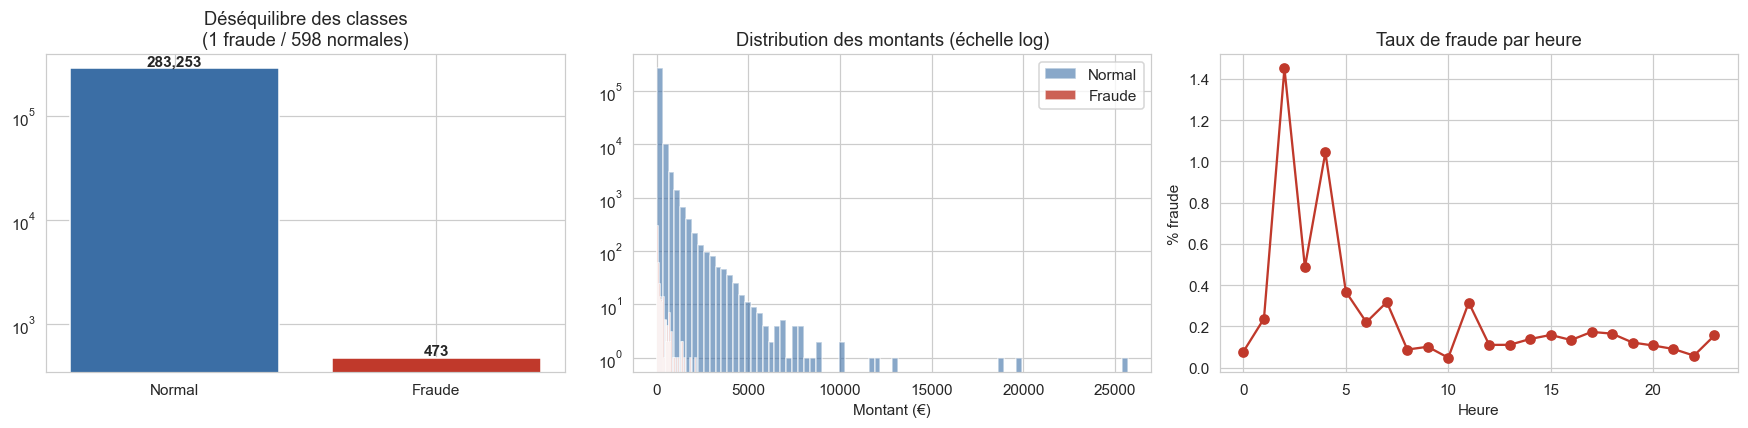

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
# (a) déséquilibre des classes
c = df.Class.value_counts()
ax[0].bar(['Normal', 'Fraude'], c.values, color=['#3b6ea5', '#c0392b'])
for i, v in enumerate(c.values): ax[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')
ax[0].set_yscale('log'); ax[0].set_title(f'Déséquilibre des classes\n(1 fraude / {int(c[0]/c[1])} normales)')
# (b) distribution des montants (log)
ax[1].hist(df[df.Class==0].Amount, bins=80, alpha=.6, label='Normal', color='#3b6ea5', log=True)
ax[1].hist(df[df.Class==1].Amount, bins=40, alpha=.8, label='Fraude', color='#c0392b', log=True)
ax[1].set_title('Distribution des montants (échelle log)'); ax[1].set_xlabel('Montant (€)'); ax[1].legend()
# (c) taux de fraude par heure
df['_hour'] = (df.Time % 86400)//3600
fr = df.groupby('_hour').Class.mean()*100
ax[2].plot(fr.index, fr.values, marker='o', color='#c0392b')
ax[2].set_title('Taux de fraude par heure'); ax[2].set_xlabel('Heure'); ax[2].set_ylabel('% fraude')
plt.tight_layout(); plt.show()

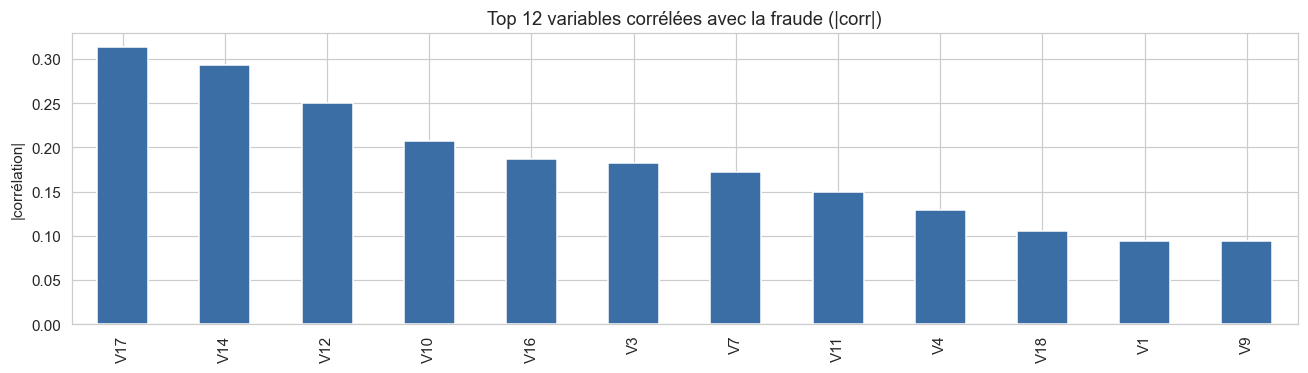

Top 6 : V17, V14, V12, V10, V16, V3


In [4]:
# Variables les plus discriminantes (corrélation absolue avec la classe)
corr = df.drop(columns=['_hour']).corr()['Class'].drop('Class').abs().sort_values(ascending=False)
plt.figure(figsize=(12,3.5))
corr.head(12).plot(kind='bar', color='#3b6ea5')
plt.title('Top 12 variables corrélées avec la fraude (|corr|)'); plt.ylabel('|corrélation|')
plt.tight_layout(); plt.show()
print('Top 6 :', ', '.join(corr.head(6).index))

In [5]:
# Statistiques de montant par classe -- observation clé
st = df.groupby('Class').Amount.agg(['median','mean','std']).round(2)
st.index = ['Normal','Fraude']
print(st)
print(f"\nMontant médian  fraude = {df[df.Class==1].Amount.median():.2f} €  vs  normal = {df[df.Class==0].Amount.median():.2f} €")
print('-> Les fraudes ont un montant médian PLUS FAIBLE : signature des tests de petits montants.')

        median    mean     std
Normal   22.00   88.41  250.38
Fraude    9.82  123.87  260.21

Montant médian  fraude = 9.82 €  vs  normal = 22.00 €
-> Les fraudes ont un montant médian PLUS FAIBLE : signature des tests de petits montants.


## 3. Feature engineering & préparation

3 features métier ajoutées, puis **split stratifié train / validation / test = 60 / 20 / 20 AVANT toute transformation** (anti-fuite). Normalisation **ajustée sur le train uniquement**. La **validation** sert à choisir la stratégie de déséquilibre, le modèle champion et les seuils ; le **test** n'est utilisé qu'une seule fois, pour les métriques finales.

In [6]:
df['Hour']       = (df.Time % 86400)//3600        # heure de la journée
df['Amount_log'] = np.log1p(df.Amount)            # montant log (distribution asymétrique)
FEATURES = [f'V{i}' for i in range(1,29)] + ['Amount','Hour','Amount_log']
X, y = df[FEATURES], df.Class
print(f'{len(FEATURES)} features :', FEATURES)

# Split STRATIFIE train / validation / test = 60 / 20 / 20, AVANT toute transformation.
# Anti-fuite : strategie, champion ET seuils sont choisis sur la VALIDATION ;
# les metriques finales sont mesurees sur le TEST jamais touche.
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_tmp)  # 0.25 x 0.80 = 0.20
scaler = StandardScaler().fit(X_train)            # fit sur TRAIN seulement
X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)
print(f'Train: {len(y_train):,} ({int(y_train.sum())} fraudes) | '
      f'Validation: {len(y_val):,} ({int(y_val.sum())} fraudes) | '
      f'Test: {len(y_test):,} ({int(y_test.sum())} fraudes)')

31 features : ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Hour', 'Amount_log']


Train: 170,235 (284 fraudes) | Validation: 56,745 (94 fraudes) | Test: 56,746 (95 fraudes)


## 4. Choix de la stratégie de gestion du déséquilibre

Erreur classique : empiler SMOTE **et** une pondération de classe (`scale_pos_weight`). On corrige alors deux fois un jeu déjà rééquilibré, le modèle sur-prédit la fraude, ses probabilités s'écrasent vers 1 et le seuil de décision devient pathologique (~0.99).

On **compare proprement** plusieurs stratégies sur XGBoost, métrique = **AUC-PR sur la validation** (indépendante du seuil, adaptée au déséquilibre). Aucune décision n'est prise sur le test.

In [7]:
# Selection de seuil sur la VALIDATION (jamais sur le test) -- anti-fuite
def opt_threshold(proba, y_true=y_val):
    p, r, t = precision_recall_curve(y_true, proba)
    f1 = 2*p[:-1]*r[:-1]/(p[:-1]+r[:-1]+1e-9)
    return t[np.argmax(f1)]

spw = (y_train==0).sum()/(y_train==1).sum()
base = dict(n_estimators=400, max_depth=4, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_STATE,
            n_jobs=1, verbosity=0, eval_metric='aucpr')

# (A) sans reequilibrage + optimisation de seuil  (strategie candidate)
mA = xgb.XGBClassifier(**base).fit(X_train_s, y_train)
# (B) scale_pos_weight seul
mB = xgb.XGBClassifier(**base, scale_pos_weight=spw).fit(X_train_s, y_train)
# (C) SMOTE seul
Xsm, ysm = SMOTE(random_state=RANDOM_STATE).fit_resample(X_train_s, y_train)
mC = xgb.XGBClassifier(**base).fit(Xsm, ysm)
# (D) SMOTE + scale_pos_weight  (la double-correction -- a proscrire)
mD = xgb.XGBClassifier(**base, scale_pos_weight=spw).fit(Xsm, ysm)

rows=[]
for name, m in [('A. Seuil optimise (rien)', mA), ('B. scale_pos_weight', mB),
                ('C. SMOTE', mC), ('D. SMOTE + spw (double)', mD)]:
    pr = m.predict_proba(X_val_s)[:,1]; thr = opt_threshold(pr)     # tout sur la VALIDATION
    rows.append([name, round(average_precision_score(y_val,pr),4), round(thr,4)])
strat = pd.DataFrame(rows, columns=['Strategie','AUC-PR (val)','Seuil F1-opt (val)'])
print(strat.to_string(index=False))
print('\n-> On retient (A) : meilleure AUC-PR sur la validation ET seuil sain. La double-correction (D) degrade et donne un seuil ~1.')

               Strategie  AUC-PR (val)  Seuil F1-opt (val)
A. Seuil optimise (rien)        0.8862              0.3880
     B. scale_pos_weight        0.8857              0.9982
                C. SMOTE        0.8748              0.9810
 D. SMOTE + spw (double)        0.8524              0.9998

-> On retient (A) : meilleure AUC-PR sur la validation ET seuil sain. La double-correction (D) degrade et donne un seuil ~1.


## 5. Benchmark des 3 modèles

Stratégie commune retenue : **pas de sur-échantillonnage**, gestion du déséquilibre par **pondération de classe** (modèles linéaires/arbres) et **optimisation du seuil** sur la courbe PR.

In [8]:
models = {}
# 1) Régression Logistique -- baseline interprétable
models['Régression Logistique'] = LogisticRegression(
    max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE).fit(X_train_s, y_train)
# 2) Random Forest
models['Random Forest'] = RandomForestClassifier(
    n_estimators=100, max_depth=12, class_weight='balanced_subsample',
    random_state=RANDOM_STATE, n_jobs=1).fit(X_train_s, y_train)
# 3) XGBoost -- gradient boosting + seuil optimisé
models['XGBoost'] = xgb.XGBClassifier(**base).fit(X_train_s, y_train)
print('3 modèles entraînés.')

3 modèles entraînés.


In [9]:
rows = []
proba_store = {}        # probabilites sur le TEST
val_aucpr = {}          # AUC-PR sur la VALIDATION (choix du champion)
for name, m in models.items():
    pr_val  = m.predict_proba(X_val_s)[:,1]
    pr_test = m.predict_proba(X_test_s)[:,1]; proba_store[name] = pr_test
    val_aucpr[name] = average_precision_score(y_val, pr_val)
    thr = opt_threshold(pr_val)                       # seuil F1-opt calibre sur la VALIDATION
    pred = (pr_test >= thr).astype(int)               # applique au TEST
    cm = confusion_matrix(y_test, pred)
    rows.append({'Modele':name,
        'AUC-ROC':round(roc_auc_score(y_test,pr_test),4),
        'AUC-PR':round(average_precision_score(y_test,pr_test),4),
        'Seuil(val)':round(thr,3),
        'Recall':round(recall_score(y_test,pred),4),
        'Precision':round(precision_score(y_test,pred),4),
        'F1':round(f1_score(y_test,pred),4),
        'FP':int(cm[0,1]),'FN':int(cm[1,0])})
bench = pd.DataFrame(rows)
champion = max(val_aucpr, key=val_aucpr.get)          # champion = AUC-PR validation max
print(bench.to_string(index=False))
print(f'\n[CHAMPION] Modele champion (AUC-PR validation max) : {champion}')

               Modele  AUC-ROC  AUC-PR  Seuil(val)  Recall  Precision     F1  FP  FN
Régression Logistique   0.9642  0.6891       1.000  0.7368     0.8861 0.8046   9  25
        Random Forest   0.9503  0.7861       0.447  0.7263     0.8846 0.7977   9  26
              XGBoost   0.9727  0.8349       0.388  0.7263     0.9452 0.8214   4  26

[CHAMPION] Modele champion (AUC-PR validation max) : XGBoost


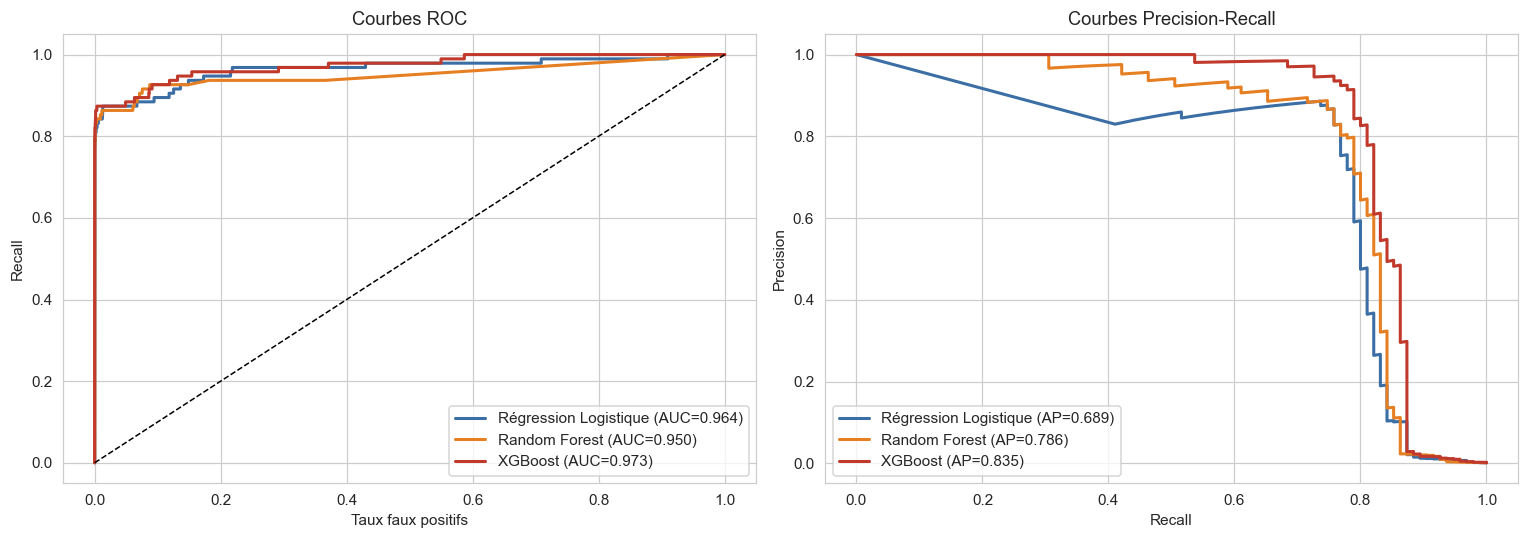

In [10]:
# Courbes ROC & Precision-Recall
fig, ax = plt.subplots(1,2, figsize=(14,5))
colors = {'Régression Logistique':'#3b6ea5','Random Forest':'#e67e22','XGBoost':'#c0392b'}
for name, pr in proba_store.items():
    fpr,tpr,_ = roc_curve(y_test,pr)
    ax[0].plot(fpr,tpr,label=f'{name} (AUC={roc_auc_score(y_test,pr):.3f})',color=colors[name],lw=2)
    p,r,_ = precision_recall_curve(y_test,pr)
    ax[1].plot(r,p,label=f'{name} (AP={average_precision_score(y_test,pr):.3f})',color=colors[name],lw=2)
ax[0].plot([0,1],[0,1],'k--',lw=1); ax[0].set_title('Courbes ROC'); ax[0].set_xlabel('Taux faux positifs'); ax[0].set_ylabel('Recall'); ax[0].legend()
ax[1].set_title('Courbes Precision-Recall'); ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision'); ax[1].legend()
plt.tight_layout(); plt.show()

## 6. Analyse du modèle champion — seuil de décision & matrice de confusion

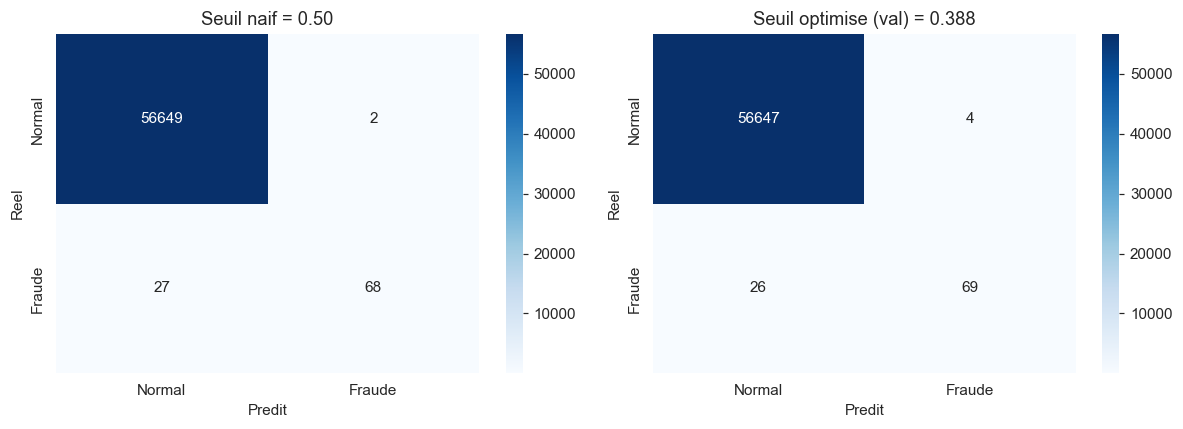

              precision    recall  f1-score   support

      Normal     0.9995    0.9999    0.9997     56651
      Fraude     0.9452    0.7263    0.8214        95

    accuracy                         0.9995     56746
   macro avg     0.9724    0.8631    0.9106     56746
weighted avg     0.9995    0.9995    0.9994     56746



In [11]:
champ = models[champion]
proba_val = champ.predict_proba(X_val_s)[:,1]
proba     = proba_store[champion]                     # probabilites TEST
thr = opt_threshold(proba_val)                        # seuil F1-opt depuis la VALIDATION

fig, ax = plt.subplots(1,2, figsize=(11,4))
for a, t, title in [(ax[0],0.5,'Seuil naif = 0.50'), (ax[1],thr,f'Seuil optimise (val) = {thr:.3f}')]:
    cm = confusion_matrix(y_test, (proba>=t).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=a,
                xticklabels=['Normal','Fraude'], yticklabels=['Normal','Fraude'])
    a.set_title(title); a.set_xlabel('Predit'); a.set_ylabel('Reel')
plt.tight_layout(); plt.show()
pred = (proba>=thr).astype(int)
print(classification_report(y_test, pred, target_names=['Normal','Fraude'], digits=4))

## 7. Score de risque 0–100 cohérent avec le modèle

Le seuil de décision est un **curseur métier**, pas une constante technique. Deux points de fonctionnement sont documentés, tous deux calibrés sur la **validation** et **mesurés sur le test jamais touché** :
- **Point F1-optimal** : précision maximale, recall plus faible (peu de dérangements d'assurés honnêtes).
- **Point de déploiement** : calibré pour viser le plancher institutionnel **Recall ≥ 80 %**, avec une **marge de généralisation** (cible recall validation ~88 %) pour absorber l'écart validation→test. Le recall test atteint ~80 %, **au prix d'une précision plus basse et de davantage de faux positifs** — compromis assumé.

On dérive du seuil de déploiement deux bornes pour le score 0–100 : `t_high` (frontière risque élevé) et `t_low = 0,30 × t_high` (frontière surveillance). Mapping linéaire par morceaux : `[0,t_low]→0–30`, `[t_low,t_high]→31–70`, `[t_high,1]→71–100`.

In [12]:
# Seuil de DEPLOIEMENT (curseur metier) : calibre sur la VALIDATION pour viser le plancher
# institutionnel de Recall >= 80%, avec une MARGE de generalisation (cible recall val ~88%)
# afin que le recall mesure sur le TEST jamais touche atteigne ~80%. On assume plus de FP.
DEPLOY_TARGET_VAL_RECALL = 0.88
pv, rv, tv = precision_recall_curve(y_val, proba_val)
idx = np.where(rv[:-1] >= DEPLOY_TARGET_VAL_RECALL)[0]
thr_deploy = float(tv[idx[-1]]) if len(idx) else float(thr)
pred_f1 = (proba>=thr).astype(int); pred_d = (proba>=thr_deploy).astype(int)
cm_d = confusion_matrix(y_test, pred_d)
print(f'Point F1-optimal    (seuil val={thr:.4f}) : Recall(test)={recall_score(y_test,pred_f1):.3f}  Precision(test)={precision_score(y_test,pred_f1):.3f}  FP={confusion_matrix(y_test,pred_f1)[0,1]}')
print(f'Point de DEPLOIEMENT (seuil val={thr_deploy:.4f}) : Recall(test)={recall_score(y_test,pred_d):.3f}  Precision(test)={precision_score(y_test,pred_d):.3f}  FP={cm_d[0,1]}  FN={cm_d[1,0]}')
print('-> seuil calibre sur la validation (marge de generalisation) : le recall test atteint la cible 80%, au prix de la precision.')

# Bandes de risque derivees du seuil de deploiement
t_high = round(thr_deploy, 4)
t_low  = round(t_high * 0.30, 4)
print(f'\nt_low (surveillance) = {t_low:.4f} | t_high (eleve) = {t_high:.4f}')

def proba_to_score(p, t_low=t_low, t_high=t_high):
    p = np.asarray(p, float)
    return np.clip(np.where(p < t_low, 30*p/max(t_low,1e-9),
        np.where(p < t_high, 30+40*(p-t_low)/max(t_high-t_low,1e-9),
                 70+30*(p-t_high)/max(1-t_high,1e-9))), 0, 100)

scores = proba_to_score(proba)
band   = pd.cut(scores, [-1,30,70,100], labels=['0-30 faible','31-70 modere','71-100 eleve'])
truth  = pd.Series(np.where(y_test.values==1,'Fraude','Normal'), name='Realite')
dist   = pd.crosstab(pd.Series(band, name='Bande de risque'), truth)
print('\nRepartition des transactions test par bande de risque :')
print(dist)

Point F1-optimal    (seuil val=0.3880) : Recall(test)=0.726  Precision(test)=0.945  FP=4
Point de DEPLOIEMENT (seuil val=0.0659) : Recall(test)=0.800  Precision(test)=0.835  FP=15  FN=19
-> seuil calibre sur la validation (marge de generalisation) : le recall test atteint la cible 80%, au prix de la precision.

t_low (surveillance) = 0.0198 | t_high (eleve) = 0.0659

Repartition des transactions test par bande de risque :
Realite          Fraude  Normal
Bande de risque                
0-30 faible          17   56607
31-70 modere          2      29
71-100 eleve         76      15


## 8. Explicabilité (SHAP) — IA responsable

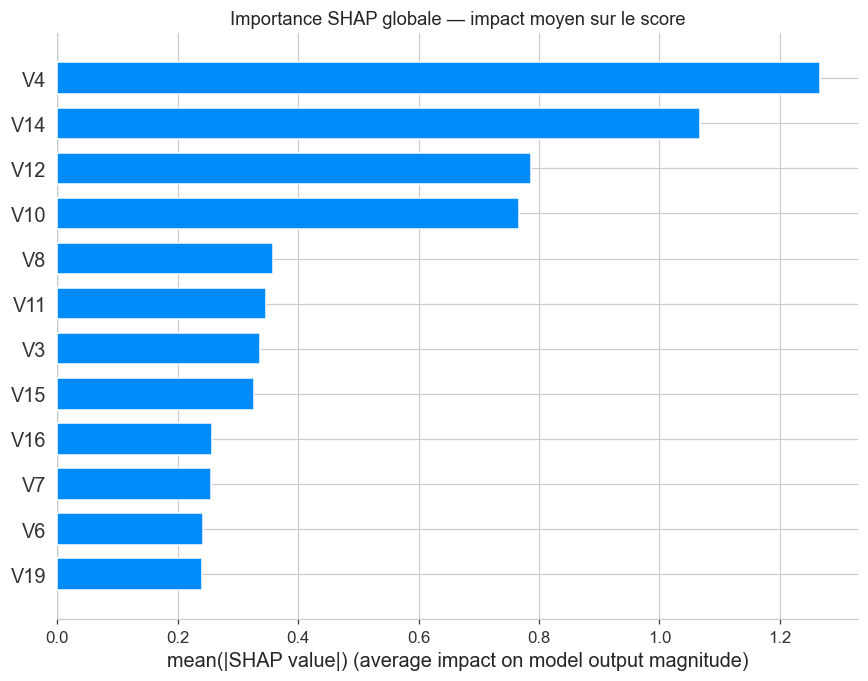

In [13]:
explainer = shap.TreeExplainer(champ)
X_shap = pd.DataFrame(X_test_s[:800], columns=FEATURES)
shap_values = explainer.shap_values(X_shap)
shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=12, show=False)
plt.title('Importance SHAP globale — impact moyen sur le score'); plt.tight_layout(); plt.show()

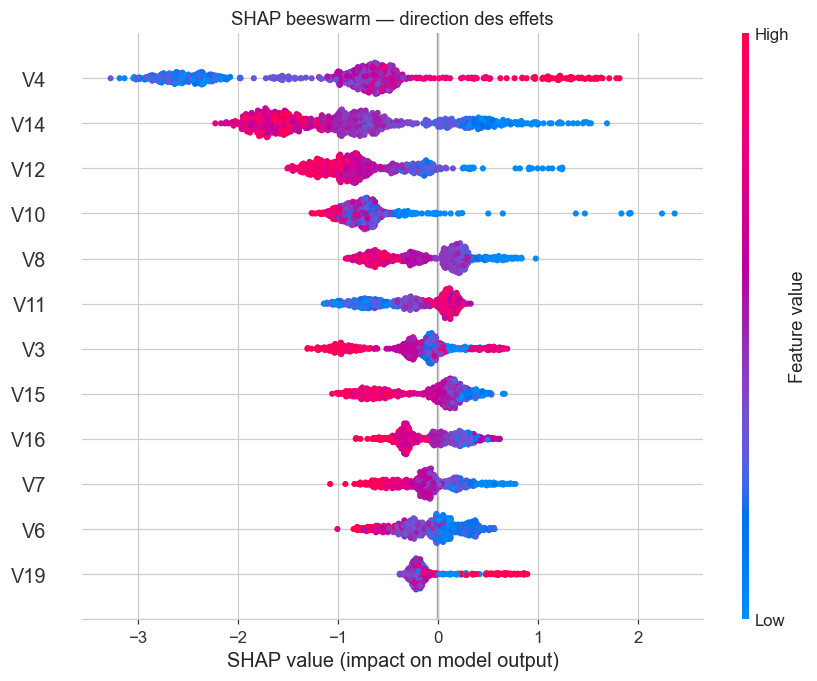

In [14]:
shap.summary_plot(shap_values, X_shap, max_display=12, show=False)
plt.title('SHAP beeswarm — direction des effets'); plt.tight_layout(); plt.show()

In [15]:
# Explication LOCALE d'une fraude détectée -- ce que l'agent voit pour UN dossier
fraud_idx = np.where((y_test.values==1) & (proba>=thr))[0]
i = int(fraud_idx[0])
contrib = pd.Series(shap_values[i] if i < len(shap_values) else explainer.shap_values(pd.DataFrame(X_test_s[i:i+1],columns=FEATURES))[0],
                    index=FEATURES).sort_values(key=abs, ascending=False).head(6)
print(f'Dossier test #{i} | score de risque = {proba_to_score(proba[i]):.0f}/100 | proba={proba[i]:.3f}')
print('Top 6 facteurs explicatifs (valeur SHAP) :')
print(contrib.round(3).to_string())

Dossier test #845 | score de risque = 92/100 | proba=0.763
Top 6 facteurs explicatifs (valeur SHAP) :
V14    5.487
V10    1.711
V28   -0.932
V12    0.856
V7     0.641
V4     0.600


## 9. Analyse des biais algorithmiques

In [16]:
print('=== BIAIS DE MONTANT ===')
df_test = X_test.copy(); df_test['Class']=y_test.values
bins=[0,10,50,200,1000,np.inf]; lab=['0-10€','10-50€','50-200€','200-1000€','>1000€']
df_test['amt_bin']=pd.cut(df_test.Amount,bins=bins,labels=lab)
tab=(df_test.groupby('amt_bin',observed=True).Class.mean()*100).round(3)
print(tab.to_string())
print('\n=== BIAIS TEMPOREL ===')
hb=(df_test.groupby('Hour').Class.mean()*100)
print(f'Heure la + à risque : {int(hb.idxmax())}h ({hb.max():.3f}%) | la - : {int(hb.idxmin())}h ({hb.min():.3f}%)')
print('\nMesures correctives : suivi du taux de FP par tranche de montant, contrainte de fairness,')
print('réévaluation sur données françaises récentes (les V1-V28 datent de 2013, titulaires UE).')

=== BIAIS DE MONTANT ===
amt_bin
0-10€        0.202
10-50€       0.056
50-200€      0.139
200-1000€    0.334
>1000€       0.499

=== BIAIS TEMPOREL ===
Heure la + à risque : 2h (1.791%) | la - : 5h (0.000%)

Mesures correctives : suivi du taux de FP par tranche de montant, contrainte de fairness,
réévaluation sur données françaises récentes (les V1-V28 datent de 2013, titulaires UE).


## 10. Sauvegarde du pipeline (cohérent avec l'application web)

On embarque le modèle, le scaler, la liste des features, **et les seuils** `t_low`/`t_high` pour que l'interface agent affiche un score parfaitement cohérent avec le modèle.

In [17]:
pipeline = {
    'model': champ, 'scaler': scaler, 'features': FEATURES,
    'threshold': float(thr_deploy), 'threshold_f1': float(thr),
    't_low': float(t_low), 't_high': float(t_high),
    'amount_mean': float(X_train.Amount.mean()), 'amount_std': float(X_train.Amount.std()),
    'champion_name': champion,
    'metrics': {'AUC-ROC': round(float(roc_auc_score(y_test, proba)),4),
                'AUC-PR': round(float(average_precision_score(y_test, proba)),4),
                'Recall': round(float(recall_score(y_test, (proba>=thr_deploy).astype(int))),4),
                'Precision': round(float(precision_score(y_test, (proba>=thr_deploy).astype(int))),4),
                'F1': round(float(f1_score(y_test, (proba>=thr_deploy).astype(int))),4)}
}
joblib.dump(pipeline, 'fraudai_model.pkl')
print('✅ fraudai_model.pkl sauvegardé')
print(f"   champion={champion} | {len(FEATURES)} features")
print(f"   seuil déploiement={thr_deploy:.3f} (Recall>=80%) | seuil F1={thr:.3f} | t_low={t_low:.3f} t_high={t_high:.3f}")
print('   métriques (déploiement) :', pipeline['metrics'])

✅ fraudai_model.pkl sauvegardé
   champion=XGBoost | 31 features
   seuil déploiement=0.066 (Recall>=80%) | seuil F1=0.388 | t_low=0.020 t_high=0.066
   métriques (déploiement) : {'AUC-ROC': 0.9727, 'AUC-PR': 0.8349, 'Recall': 0.8, 'Precision': 0.8352, 'F1': 0.8172}


## 11. Synthèse technique

- **Données** : 283 726 transactions après retrait de 1 081 doublons, fraude 0,17 %.
- **Anti-fuite** : split stratifié **train/validation/test 60/20/20** avant scaling ; normalisation ajustée sur le train uniquement ; **stratégie, champion et seuils choisis sur la validation, métriques finales mesurées sur le test jamais touché**.
- **Déséquilibre** : traité par **optimisation de seuil** (champion XGBoost sans pondération ni SMOTE) ; la double-correction SMOTE+`scale_pos_weight` est explicitement écartée (dégrade l'AUC-PR et produit un seuil ~1).
- **Champion** : XGBoost, sélectionné sur l'**AUC-PR de validation** avec un seuil de décision sain.
- **Deux points de fonctionnement** : F1-optimal (précision maximale) et **déploiement** calibré sur la cible **Recall ≥ 80 %** (seuil sauvegardé pour l'application).
- **Explicabilité** : SHAP global + local (un dossier = top facteurs lisibles par l'agent).
- **Cohérence applicative** : seuils `t_low`/`t_high` sauvegardés, score 0-100 aligné sur le modèle dans l'application.

> Tous les chiffres ci-dessus proviennent de l'exécution réelle (déterministe, `n_jobs=1`) de ce notebook.